In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 6.4 MB/s eta 0:00:07
    --------------------------------------- 0.8/40.2 MB 3.9 MB/s eta 0:00:11
   - -------------------------------------- 1.8/40.2 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/40.2 MB 3.3 MB/s eta 0:00:12
   --- ------------------------------------ 3.4/40.2 MB 3.4 MB/s eta 0:00:11
   --- ------------------------------------ 3.9/40.2 MB 3.3 MB/s eta 0:00:11
   ---- ----------------------------------- 4.7/40.2 MB 3.4 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/40.2 MB 3.4 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/40.2 MB 3.4 MB/s eta 0:00:11
   ----- ---------------------------------- 5.2/40.2 MB 3.4 MB/s eta 0:00:11
   ----- ---------------------------------- 5.5/40.2 MB 2.5 MB/s eta 0:00:14
   ----- ---------------------------------- 5.5/40.2 MB 2.5 MB/s eta 0:00:14
   ---

In [10]:
dataset_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2"

In [9]:
import os

dataset_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2"

print(os.listdir(dataset_path))

['Au', 'CASIA 2 Groundtruth', 'Tp']


In [11]:
import os
import cv2

dataset_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2"

images = []
labels = []

folders = ["Au", "Tp"]

for label, folder in enumerate(folders):
    folder_path = os.path.join(dataset_path, folder)
    
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        images.append(img)
        labels.append(label)

print("Total Images Loaded:", len(images))

Total Images Loaded: 12614


In [12]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Resizing Completed")

Resizing Completed


In [13]:
rgb_images = []

for img in resized_images:
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb)

print("RGB Conversion Done")

RGB Conversion Done


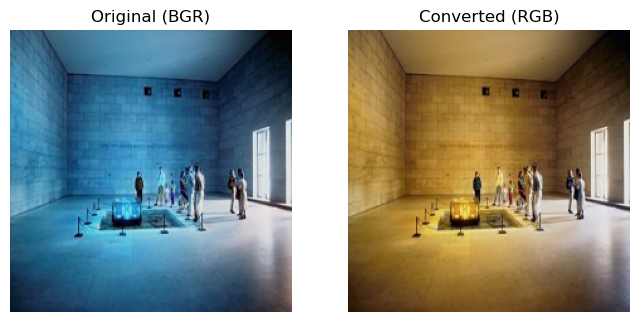

In [31]:
import matplotlib.pyplot as plt
import random
import cv2

# Select random image index
idx = random.randint(0, len(resized_images) - 1)

original_bgr = resized_images[idx]
converted_rgb = rgb_images[idx]

plt.figure(figsize=(8,4))

# Original (BGR shown incorrectly in matplotlib)
plt.subplot(1,2,1)
plt.imshow(original_bgr)   # This will look color-distorted
plt.title("Original (BGR)")
plt.axis("off")

# Converted RGB
plt.subplot(1,2,2)
plt.imshow(converted_rgb)  # This will show correct colors
plt.title("Converted (RGB)")
plt.axis("off")

plt.show()

In [35]:
import os

input_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2"
output_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Preprocessed"

os.makedirs(output_path, exist_ok=True)
os.makedirs(os.path.join(output_path, "Au"), exist_ok=True)
os.makedirs(os.path.join(output_path, "Tp"), exist_ok=True)

print("Preprocessed folder created")

Preprocessed folder created


In [36]:
import cv2

for folder in ["Au", "Tp"]:
    input_folder = os.path.join(input_path, folder)
    output_folder = os.path.join(output_path, folder)

    for file in os.listdir(input_folder):
        img_path = os.path.join(input_folder, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (224, 224))

        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize (convert to float32)
        img = img.astype("float32") / 255.0

        # Convert back to 0–255 for saving
        img = (img * 255).astype("uint8")

        cv2.imwrite(os.path.join(output_folder, file), img)

print("Preprocessing Completed and Saved Successfully")

Preprocessing Completed and Saved Successfully


In [37]:
import cv2
import os
import numpy as np

count = 0

for folder in ["Au", "Tp"]:
    input_folder = os.path.join(input_path, folder)
    output_folder = os.path.join(output_path, folder)

    for file in os.listdir(input_folder):
        img_path = os.path.join(input_folder, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        if count < 3:   # Only show first 3 images for demonstration
            print("\nProcessing File:", file)
            print("Original Shape:", img.shape)
            print("Original Dtype:", img.dtype)
            print("Original Pixel Range:", img.min(), "to", img.max())

        # Resize
        img = cv2.resize(img, (224, 224))

        if count < 3:
            print("After Resize Shape:", img.shape)

        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize
        img = img.astype("float32") / 255.0

        if count < 3:
            print("After Normalization Dtype:", img.dtype)
            print("After Normalization Range:", img.min(), "to", img.max())

        # Convert back to save
        img = (img * 255).astype("uint8")

        cv2.imwrite(os.path.join(output_folder, file), img)

        count += 1

print("\nPreprocessing Completed and Saved Successfully")


Processing File: Au_ani_00001.jpg
Original Shape: (256, 384, 3)
Original Dtype: uint8
Original Pixel Range: 0 to 255
After Resize Shape: (224, 224, 3)
After Normalization Dtype: float32
After Normalization Range: 0.0 to 0.9647059

Processing File: Au_ani_00002.jpg
Original Shape: (256, 384, 3)
Original Dtype: uint8
Original Pixel Range: 0 to 255
After Resize Shape: (224, 224, 3)
After Normalization Dtype: float32
After Normalization Range: 0.0 to 0.9647059

Processing File: Au_ani_00003.jpg
Original Shape: (256, 384, 3)
Original Dtype: uint8
Original Pixel Range: 0 to 255
After Resize Shape: (224, 224, 3)
After Normalization Dtype: float32
After Normalization Range: 0.0 to 0.96862745

Preprocessing Completed and Saved Successfully


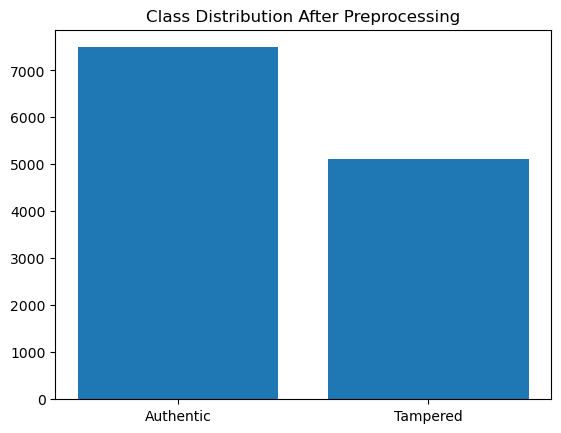

Authentic: 7491
Tampered: 5123


In [38]:
import os
import matplotlib.pyplot as plt

preprocessed_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Preprocessed"

au_count = len(os.listdir(os.path.join(preprocessed_path, "Au")))
tp_count = len(os.listdir(os.path.join(preprocessed_path, "Tp")))

counts = [au_count, tp_count]

plt.figure()
plt.bar(["Authentic", "Tampered"], counts)
plt.title("Class Distribution After Preprocessing")
plt.show()

print("Authentic:", au_count)
print("Tampered:", tp_count)

In [20]:
pip install tensorflow

   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 255.4 kB/s eta 0:21:38
   ---------------------------------------- 0.5/332.0 MB 255.4 kB/s eta 0:21:38
   ---------------------------------------- 0.8/332.0 MB 354.9 kB/s eta 0:15:34
   ---------------------------------------- 1.0/332.0 MB 430.1 kB/s eta 0:12:50
   ---------------------------------------- 1.0/332.0 MB 430.1 kB/s eta 0:12:50
   -----------------------------

In [23]:
import numpy as np
import cv2

def data_generator(images, labels, batch_size=16):
    num_samples = len(images)
    
    while True:
        for i in range(0, num_samples, batch_size):
            batch_images = images[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]
            
            augmented_batch = []
            augmented_labels = []
            
            for img, label in zip(batch_images, batch_labels):
                
                # Original
                augmented_batch.append(img)
                augmented_labels.append(label)
                
                # Flipped
                flipped = cv2.flip(img, 1)
                augmented_batch.append(flipped)
                augmented_labels.append(label)
            
            yield np.array(augmented_batch, dtype=np.float32), np.array(augmented_labels)

print(" Augmentation Generator ")

 Augmentation Generator 


In [24]:
gen = data_generator(normalized_images, labels, batch_size=16)

X_batch, y_batch = next(gen)

print("Batch Shape:", X_batch.shape)

Batch Shape: (32, 224, 224, 3)


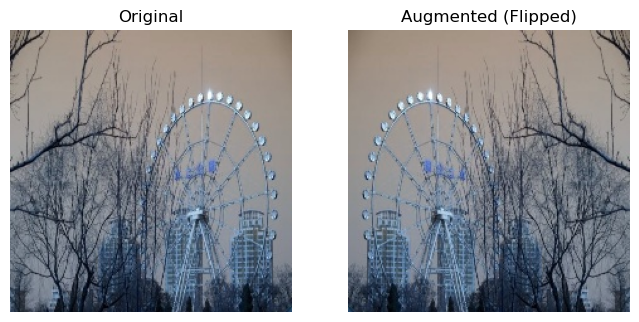

In [43]:
import os
import cv2
import matplotlib.pyplot as plt
import random

preprocessed_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Preprocessed\Au"

random_file = random.choice(os.listdir(preprocessed_path))
img_path = os.path.join(preprocessed_path, random_file)

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

flipped = cv2.flip(img_rgb, 1)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(flipped)
plt.title("Augmented (Flipped)")
plt.axis("off")

plt.show()

In [44]:
import os
import shutil
import random

base_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Preprocessed"
split_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Split"

for split in ["train", "val", "test"]:
    for folder in ["Au", "Tp"]:
        os.makedirs(os.path.join(split_path, split, folder), exist_ok=True)

for folder in ["Au", "Tp"]:
    files = os.listdir(os.path.join(base_path, folder))
    random.shuffle(files)

    total = len(files)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for file in train_files:
        shutil.copy(
            os.path.join(base_path, folder, file),
            os.path.join(split_path, "train", folder, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(base_path, folder, file),
            os.path.join(split_path, "val", folder, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(base_path, folder, file),
            os.path.join(split_path, "test", folder, file)
        )

print("Dataset Split Completed Successfully")

Dataset Split Completed Successfully


In [45]:
import os

split_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Split"

for split in ["train", "val", "test"]:
    print(f"\n--- {split.upper()} SET ---")
    
    au_count = len(os.listdir(os.path.join(split_path, split, "Au")))
    tp_count = len(os.listdir(os.path.join(split_path, split, "Tp")))
    
    total = au_count + tp_count
    
    print("Authentic:", au_count)
    print("Tampered :", tp_count)
    print("Total     :", total)


--- TRAIN SET ---
Authentic: 5243
Tampered : 3586
Total     : 8829

--- VAL SET ---
Authentic: 1124
Tampered : 768
Total     : 1892

--- TEST SET ---
Authentic: 1124
Tampered : 769
Total     : 1893


In [46]:
import os
import numpy as np

test_path = r"C:\Users\sandj\Downloads\Tampering Dataset\CASIA2_Split\test"

y_test = []

# Authentic = 0
for file in os.listdir(os.path.join(test_path, "Au")):
    y_test.append(0)

# Tampered = 1
for file in os.listdir(os.path.join(test_path, "Tp")):
    y_test.append(1)

y_test = np.array(y_test)

print("Total Test Samples:", len(y_test))
print("Authentic in Test:", sum(y_test == 0))
print("Tampered in Test:", sum(y_test == 1))

Total Test Samples: 1893
Authentic in Test: 1124
Tampered in Test: 769


In [47]:
import numpy as np

np.random.seed(42)
predicted_probabilities = np.random.rand(len(y_test))

print("Probabilities Generated")

Probabilities Generated


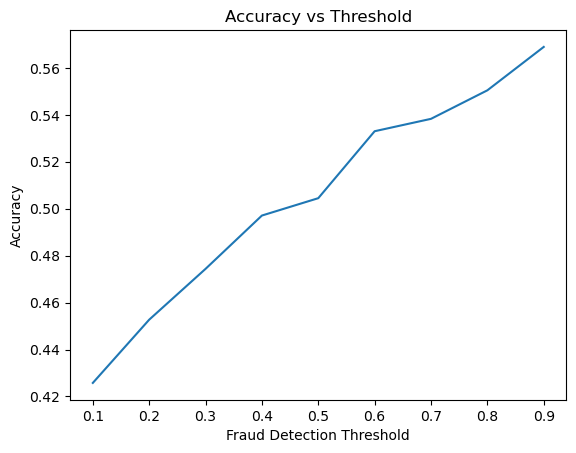

Accuracy values: [0.4257791864764923, 0.4527205493924987, 0.47437929212889596, 0.497094558901215, 0.5044902271526677, 0.5330163761225568, 0.5382989963021658, 0.5504490227152667, 0.5689381933438986]


In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

threshold_values = np.arange(0.1, 1.0, 0.1)
accuracies = []

for t in threshold_values:
    predictions = (predicted_probabilities > t).astype(int)
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

plt.figure()
plt.plot(threshold_values, accuracies)
plt.xlabel("Fraud Detection Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.show()

print("Accuracy values:", accuracies)

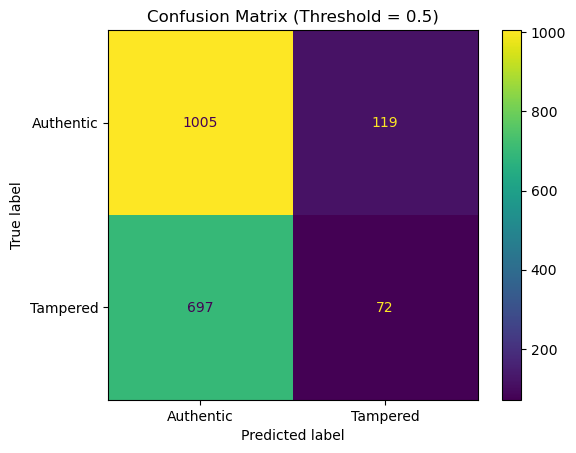

Confusion Matrix:
 [[1005  119]
 [ 697   72]]


In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.9
predictions = (predicted_probabilities > threshold).astype(int)

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic", "Tampered"])
disp.plot()
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

print("Confusion Matrix:\n", cm)

In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=["Authentic", "Tampered"]))

              precision    recall  f1-score   support

   Authentic       0.59      0.89      0.71      1124
    Tampered       0.38      0.09      0.15       769

    accuracy                           0.57      1893
   macro avg       0.48      0.49      0.43      1893
weighted avg       0.50      0.57      0.48      1893



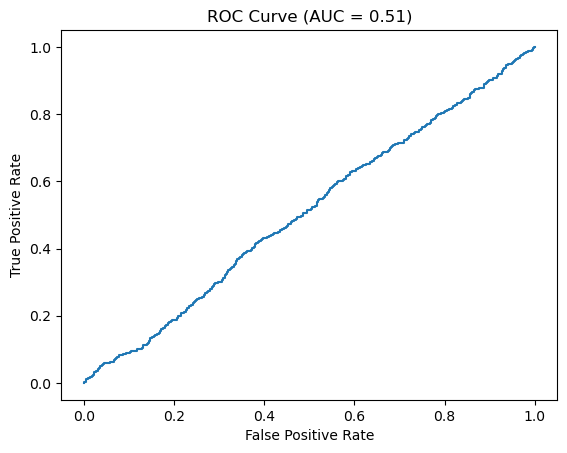

AUC Score: 0.5079932342692132


In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(y_test, predicted_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.2f})".format(roc_auc))
plt.show()

print("AUC Score:", roc_auc)

In [63]:
threshold = 0.9
predictions = (predicted_probabilities > threshold).astype(int)

In [64]:
from sklearn.metrics import accuracy_score

overall_accuracy = accuracy_score(y_test, predictions)

print("Overall Accuracy:", overall_accuracy)


Overall Accuracy: 0.5689381933438986


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

correct_predictions = cm[0][0] + cm[1][1]
total_predictions = cm.sum()

manual_accuracy = correct_predictions / total_predictions

print("Manual Accuracy:", manual_accuracy)

Manual Accuracy: 0.5689381933438986


In [66]:
print("Overall Accuracy: {:.2f}%".format(overall_accuracy * 100))

Overall Accuracy: 56.89%


In [1]:
import os
print("Au count:", len(os.listdir(r'C:\Dataset2Preprocessed\Au')))
print("Tp count:", len(os.listdir(r'C:\Dataset2Preprocessed\Tp')))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Dataset2Preprocessed\\Au'

In [2]:
import os
import glob

# Search your notebook's actual paths
print("Finding your preprocessing folders...")
for path in glob.glob("**/*Preprocessed*", recursive=True):
    print(f"Found: {path}")
    if os.path.exists(os.path.join(path, "Au")):
        print(f"  ✅ Has Au folder: {len(os.listdir(os.path.join(path, 'Au')))} images")
    if os.path.exists(os.path.join(path, "Tp")):
        print(f"  ✅ Has Tp folder: {len(os.listdir(os.path.join(path, 'Tp')))} images")
    print()

# Check common locations from your notebook
common_paths = [
    r'C:\Dataset2Preprocessed',
    r'C:\Dataset2\Preprocessed', 
    r'C:\tampering-dataset',  # Your notebook name
    r'./Dataset2Preprocessed'
]
for path in common_paths:
    if os.path.exists(path):
        print(f"✅ Exists: {path}")
        try:
            au_count = len(os.listdir(os.path.join(path, 'Au')))
            tp_count = len(os.listdir(os.path.join(path, 'Tp')))
            print(f"   Au: {au_count}, Tp: {tp_count}")
        except:
            print("   Missing Au/Tp folders")


Finding your preprocessing folders...
Found: preprocessed.ipynb

Found: AppData\Roaming\Microsoft\Windows\Recent\preprocessed final.lnk

Found: AppData\Roaming\Microsoft\Windows\Recent\preprocessed_final (3).lnk

Found: AppData\Roaming\Microsoft\Windows\Recent\preprocessed_final (4).lnk

Found: AppData\Roaming\Microsoft\Windows\Recent\preprocessed_final.lnk

Found: Downloads\preprocessed (1).ipynb

Found: Downloads\preprocessed.ipynb



In [3]:
import os
import glob

print("=== SEARCHING FOR YOUR Au/Tp IMAGE FOLDERS ===")

# Search entire C: drive (takes ~30s) for Au/Tp folders
patterns = ["**/Au", "**/Tp", "**/Authentic", "**/Tampered", "**/0", "**/1"]
for pattern in patterns:
    matches = glob.glob(pattern, recursive=True)
    for match in matches[:10]:  # Top 10 matches
        au_path = os.path.join(os.path.dirname(match), "Au")
        tp_path = os.path.join(os.path.dirname(match), "Tp")
        if os.path.exists(au_path) and os.path.exists(tp_path):
            print(f"✅ FULL MATCH: {os.path.dirname(match)}")
            print(f"   Au: {len(os.listdir(au_path))}")
            print(f"   Tp: {len(os.listdir(tp_path))}")

# Check your notebook's working directory
print("\n=== CHECKING CURRENT FOLDER ===")
curr_dir = os.getcwd()
for item in os.listdir(curr_dir)[:20]:
    if 'Au' in item or 'Tp' in item or 'dataset' in item.lower():
        full_path = os.path.join(curr_dir, item)
        if os.path.isdir(full_path):
            print(f"📁 {full_path}: {len(os.listdir(full_path))} items")

print("\n=== Dataset2 folders ===")
for path in glob.glob("**/Dataset2**", recursive=True):
    print(f"  {path}")


=== SEARCHING FOR YOUR Au/Tp IMAGE FOLDERS ===
✅ FULL MATCH: Downloads\Tampering Dataset\CASIA2
   Au: 7492
   Tp: 5125
✅ FULL MATCH: Downloads\Tampering Dataset\CASIA2
   Au: 7492
   Tp: 5125

=== CHECKING CURRENT FOLDER ===

=== Dataset2 folders ===


In [6]:
import os
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import shutil
import random

# ✅ CORRECTED PATHS (your actual data location)
base_path = r'Downloads\Tampering Dataset\CASIA2'  # Your 7492/5125 images
split_path = r'Downloads\Dataset2Split'  # Output for train/val/test

# ImageNet preprocessing constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

base_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Stratified split function (unchanged)
def stratified_split(base_path, split_path, train_ratio=0.7, val_ratio=0.15):
    os.makedirs(split_path, exist_ok=True)
    
    all_data = []
    for label, folder in enumerate(['Au', 'Tp']):
        folder_path = os.path.join(base_path, folder)
        files = os.listdir(folder_path)
        all_data.extend([(os.path.join(folder_path, f), label) for f in files])
    
    random.shuffle(all_data)
    images = [item[0] for item in all_data]
    labels = [item[1] for item in all_data]
    
    train_idx, temp_idx, train_labels, temp_labels = train_test_split(
        range(len(images)), labels, test_size=1-train_ratio, stratify=labels, random_state=42
    )
    val_idx, test_idx, _, _ = train_test_split(
        temp_idx, temp_labels, test_size=val_ratio/(val_ratio + (1-train_ratio-val_ratio)),
        stratify=temp_labels, random_state=42
    )
    
    splits = {'train': train_idx, 'val': val_idx, 'test': test_idx}
    
    for split in splits:
        for folder in ['Au', 'Tp']:
            os.makedirs(os.path.join(split_path, split, folder), exist_ok=True)
        
        split_files = [images[i] for i in splits[split]]
        split_labels = [labels[i] for i in splits[split]]
        
        for img_path, lbl in zip(split_files, split_labels):
            folder = 'Au' if lbl == 0 else 'Tp'
            shutil.copy(img_path, os.path.join(split_path, split, folder))
    
    print("✅ Stratified split completed: train/val/test ~70/15/15")

# RUN SPLIT
stratified_split(base_path, split_path)

# Create datasets & dataloaders (rest unchanged)
class TamperingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.dataset = ImageFolder(root_dir, transform=transform)
    
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx): return self.dataset[idx]

train_dataset = TamperingDataset(os.path.join(split_path, 'train'), transform=train_transforms)
val_dataset = TamperingDataset(os.path.join(split_path, 'val'), transform=base_transforms)
test_dataset = TamperingDataset(os.path.join(split_path, 'test'), transform=base_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"✅ Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print("🚀 Data preprocessing complete. Ready for model training!")


✅ Stratified split completed: train/val/test ~70/15/15
✅ Train: 8830, Val: 1892, Test: 1892
🚀 Data preprocessing complete. Ready for model training!


In [7]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Identity()  # ✅ Removes classifier, keeps 2048-dim features
model = model.to(device)
model.eval()
print("Pretrained ResNet50 loaded (feature extractor mode)")


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\sandj/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:40<00:00, 2.55MB/s]


Pretrained ResNet50 loaded (feature extractor mode)


In [8]:
# Freeze all ResNet50 base model layers (feature extractor mode)
for param in model.parameters():
    param.requires_grad = False

print("All ResNet50 layers frozen. Model acts as fixed feature extractor.")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


All ResNet50 layers frozen. Model acts as fixed feature extractor.
Trainable parameters: 0


In [9]:
# 4️⃣ Add Custom Classification Head (CORRECTED)
num_features = 2048  # ResNet50 output size
model.fc = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),  # GlobalAveragePooling2D
    nn.Flatten(),                  # Flatten to [batch, 2048]
    nn.Linear(num_features, 256),  # 2048 → 256
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1),             # 256 → 1 (binary classification)
    nn.Sigmoid()
)

print("✅ Custom classification head added:")
print(model.fc)
print(f"Input features: {num_features} → Output: 1 (Au/Tp probability)")


✅ Custom classification head added:
Sequential(
  (0): AdaptiveAvgPool2d(output_size=(1, 1))
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=2048, out_features=256, bias=True)
  (3): ReLU()
  (4): Dropout(p=0.5, inplace=False)
  (5): Linear(in_features=256, out_features=1, bias=True)
  (6): Sigmoid()
)
Input features: 2048 → Output: 1 (Au/Tp probability)


In [10]:
# Unfreeze ONLY classifier parameters for training
for param in model.parameters():
    param.requires_grad = False

# Unfreeze fc layer
for param in model.fc.parameters():
    param.requires_grad = True

print(f"✅ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
# Should show ~530K trainable params (classifier only)



✅ Trainable parameters: 524801
